
Generated stop demand:
Stop 1: demand = 193
Stop 2: demand = 103
Stop 3: demand = 365
Stop 4: demand = 148
Stop 5: demand = 228
Stop 6: demand = 294
Stop 7: demand = 153
Stop 8: demand = 356
Stop 9: demand = 140
Stop 10: demand = 372

Total demand: 2352

Solving with demand loss limit <= 1411...

Solving with demand loss limit <= 1058...

Solving with demand loss limit <= 705...

Solving with demand loss limit <= 352...

Solving with demand loss limit <= 0...

No feasible incumbent solution found.
Gurobi status: 9

GUROBI EPSILON-CONSTRAINT BENCHMARK RESULTS
Solution   Distance        Demand Loss     Served Demand   Runtime    MIP Gap   
1          14.699          1259.0          1093.0          0.153      0.00000   
2          16.976          1031.0          1321.0          0.370      0.00000   
3          22.526          619.0           1733.0          1.065      0.00000   
4          29.472          243.0           2109.0          1.073      0.00000   

----------------------------

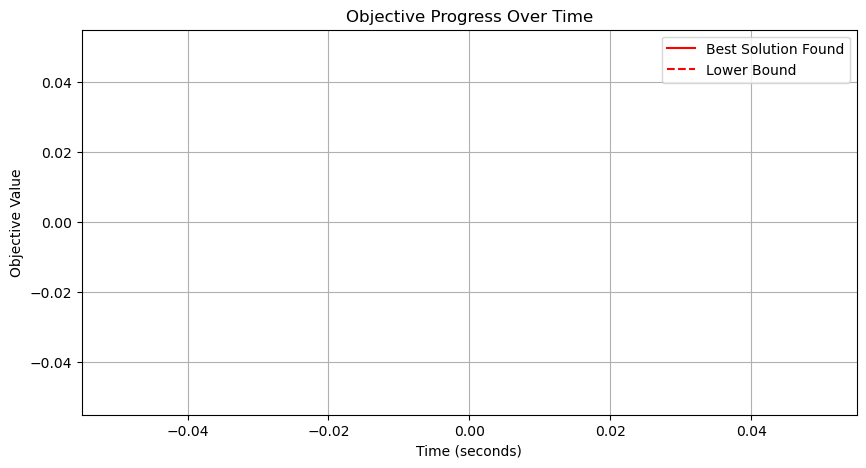

In [5]:
"""
Small-sized Gurobi benchmark for bi-objective bus route redesign.

Problem:
    Multiple TSP / bus route redesign.

Objectives:
    1. Minimise total route distance.
    2. Minimise demand loss.

Bi-objective method:
    Epsilon-constraint method:
        Minimise total distance subject to demand loss <= epsilon.

Node 0 = bus interchange 
Nodes 1 to n = bus stops.
"""

import math
import random
from gurobipy import Model, GRB, quicksum
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np


# ============================================================
# 1. Generate small synthetic data
# ============================================================

def generate_data(num_stops=10, num_services=3, seed=42):
    random.seed(seed)

    depot = 0
    stops = list(range(1, num_stops + 1))
    nodes = [depot] + stops
    services = list(range(num_services))

    # Generate coordinates in a 10 km by 10 km area
    coords = {depot: (5.0, 5.0)}

    for i in stops:
        coords[i] = (
            random.uniform(0, 10),
            random.uniform(0, 10)
        )

    # Euclidean distance matrix
    distance = {}

    for i in nodes:
        for j in nodes:
            if i != j:
                xi, yi = coords[i]
                xj, yj = coords[j]
                distance[i, j] = math.sqrt((xi - xj) ** 2 + (yi - yj) ** 2)

    # Peak-period demand at each stop
    demand = {
        i: random.randint(80, 500)
        for i in stops
    }

    return nodes, stops, depot, services, coords, distance, demand


# ============================================================
# 2. Solve one epsilon-constraint model
# ============================================================

def solve_bus_route_gurobi(
    nodes,
    stops,
    depot,
    services,
    distance,
    demand,
    max_stops_per_service=4,
    max_distance_per_service=None,
    demand_loss_limit=None,
    time_limit=180,
    verbose=False
):
    model = Model("bus_route_redesign_mtsp")

    if not verbose:
        model.Params.OutputFlag = 0

    model.Params.TimeLimit = time_limit
    model.Params.MIPFocus = 1

    Z = services
    N = nodes
    V = stops
    K = max_stops_per_service

    # ------------------------------------------------------------
    # Decision variables
    # ------------------------------------------------------------

    x = {}

    for z in Z:
        for i in N:
            for j in N:
                if i != j:
                    x[z, i, j] = model.addVar(
                        vtype=GRB.BINARY,
                        name=f"x_{z}_{i}_{j}"
                    )

    y = {}

    for z in Z:
        for i in V:
            y[z, i] = model.addVar(
                vtype=GRB.BINARY,
                name=f"y_{z}_{i}"
            )

    u = {}

    for i in V:
        u[i] = model.addVar(
            vtype=GRB.BINARY,
            name=f"u_{i}"
        )

    order = {}

    for z in Z:
        for i in V:
            order[z, i] = model.addVar(
                lb=0,
                ub=K,
                vtype=GRB.CONTINUOUS,
                name=f"order_{z}_{i}"
            )

    model.update()

    # ------------------------------------------------------------
    # Routing constraints
    # ------------------------------------------------------------

    # Each service leaves depot exactly once
    for z in Z:
        model.addConstr(
            quicksum(x[z, depot, j] for j in V) == 1,
            name=f"depart_depot_{z}"
        )

    # Each service returns to depot exactly once
    for z in Z:
        model.addConstr(
            quicksum(x[z, i, depot] for i in V) == 1,
            name=f"return_depot_{z}"
        )

    # Link assignment to route inflow and outflow
    for z in Z:
        for i in V:
            model.addConstr(
                quicksum(x[z, i, j] for j in N if j != i) == y[z, i],
                name=f"outflow_link_{z}_{i}"
            )

            model.addConstr(
                quicksum(x[z, j, i] for j in N if j != i) == y[z, i],
                name=f"inflow_link_{z}_{i}"
            )

    # Each stop can be assigned to at most one service
    for i in V:
        model.addConstr(
            quicksum(y[z, i] for z in Z) <= 1,
            name=f"at_most_one_service_{i}"
        )

    # Define coverage variable
    for i in V:
        model.addConstr(
            u[i] == quicksum(y[z, i] for z in Z),
            name=f"coverage_{i}"
        )

    # Maximum number of stops per service
    for z in Z:
        model.addConstr(
            quicksum(y[z, i] for i in V) <= K,
            name=f"max_stops_service_{z}"
        )

    # Optional maximum route distance per service
    if max_distance_per_service is not None:
        for z in Z:
            model.addConstr(
                quicksum(
                    distance[i, j] * x[z, i, j]
                    for i in N
                    for j in N
                    if i != j
                ) <= max_distance_per_service,
                name=f"max_route_distance_{z}"
            )

    # ------------------------------------------------------------
    # MTZ subtour elimination
    # ------------------------------------------------------------

    for z in Z:
        for i in V:
            model.addConstr(
                order[z, i] >= y[z, i],
                name=f"order_lower_{z}_{i}"
            )

            model.addConstr(
                order[z, i] <= K * y[z, i],
                name=f"order_upper_{z}_{i}"
            )

        for i in V:
            for j in V:
                if i != j:
                    model.addConstr(
                        order[z, i] - order[z, j] + K * x[z, i, j]
                        <= K - 1,
                        name=f"mtz_{z}_{i}_{j}"
                    )

    # ------------------------------------------------------------
    # Demand loss
    # ------------------------------------------------------------

    total_demand = sum(demand[i] for i in V)

    served_demand = quicksum(
        demand[i] * u[i]
        for i in V
    )

    demand_loss = total_demand - served_demand

    if demand_loss_limit is not None:
        model.addConstr(
            demand_loss <= demand_loss_limit,
            name="demand_loss_limit"
        )

    # ------------------------------------------------------------
    # Objective: minimise total distance
    # ------------------------------------------------------------

    total_distance = quicksum(
        distance[i, j] * x[z, i, j]
        for z in Z
        for i in N
        for j in N
        if i != j
    )

    model.setObjective(total_distance, GRB.MINIMIZE)

    # ------------------------------------------------------------
    # Solve
    # ------------------------------------------------------------

    model.optimize()

    # Important fix:
    # Do not read .X if no solution exists.
    if model.SolCount == 0:
        print("\nNo feasible incumbent solution found.")
        print("Gurobi status:", model.Status)

        if model.Status == GRB.INFEASIBLE:
            print("Model is infeasible. Computing IIS...")
            model.computeIIS()
            model.write("infeasible_model.ilp")
            print("IIS written to infeasible_model.ilp")

        return None

    # ------------------------------------------------------------
    # Extract routes safely
    # ------------------------------------------------------------

    routes = {}

    for z in Z:
        route = [depot]
        current = depot
        visited_in_route = set()

        while True:
            next_node = None

            for j in N:
                if current != j:
                    var = x.get((z, current, j))

                    if var is not None and var.X > 0.5:
                        next_node = j
                        break

            if next_node is None:
                break

            route.append(next_node)

            if next_node == depot:
                break

            if next_node in visited_in_route:
                print(f"Warning: cycle detected in route for service {z}.")
                break

            visited_in_route.add(next_node)
            current = next_node

        routes[z] = route

    selected_stops = [
        i for i in V
        if u[i].X > 0.5
    ]

    unserved_stops = [
        i for i in V
        if u[i].X < 0.5
    ]

    result = {
        "status": model.Status,
        "objective_distance": total_distance.getValue(),
        "demand_loss": demand_loss.getValue(),
        "served_demand": served_demand.getValue(),
        "total_demand": total_demand,
        "runtime": model.Runtime,
        "mip_gap": model.MIPGap if model.SolCount > 0 else None,
        "routes": routes,
        "selected_stops": selected_stops,
        "unserved_stops": unserved_stops,
        "demand": demand,
        "coords": None
    }

    return result


# ============================================================
# 3. Epsilon-constraint experiment
# ============================================================

def run_epsilon_constraint_experiment():
    nodes, stops, depot, services, coords, distance, demand = generate_data(
        num_stops=10,
        num_services=3,
        seed=7
    )

    total_demand = sum(demand[i] for i in stops)

    print("\nGenerated stop demand:")
    for i in stops:
        print(f"Stop {i}: demand = {demand[i]}")

    print("\nTotal demand:", total_demand)

    # Because 3 services x 4 stops each = maximum 12 stops,
    # all 10 stops can theoretically be served.
    epsilon_values = [
        int(total_demand * 0.60),
        int(total_demand * 0.45),
        int(total_demand * 0.30),
        int(total_demand * 0.15),
        0
    ]

    pareto_results = []

    for eps in epsilon_values:
        print(f"\nSolving with demand loss limit <= {eps}...")

        result = solve_bus_route_gurobi(
            nodes=nodes,
            stops=stops,
            depot=depot,
            services=services,
            distance=distance,
            demand=demand,
            max_stops_per_service=4,
            max_distance_per_service=None,
            demand_loss_limit=eps,
            time_limit=180,
            verbose=False
        )

        if result is not None:
            pareto_results.append(result)

    # Remove duplicate solutions
    unique_results = []
    seen = set()

    for result in pareto_results:
        key = (
            round(result["objective_distance"], 4),
            round(result["demand_loss"], 4)
        )

        if key not in seen:
            seen.add(key)
            unique_results.append(result)

    print("\n" + "=" * 90)
    print("GUROBI EPSILON-CONSTRAINT BENCHMARK RESULTS")
    print("=" * 90)

    print(
        f"{'Solution':<10} "
        f"{'Distance':<15} "
        f"{'Demand Loss':<15} "
        f"{'Served Demand':<15} "
        f"{'Runtime':<10} "
        f"{'MIP Gap':<10}"
    )

    for idx, result in enumerate(unique_results, start=1):
        print(
            f"{idx:<10} "
            f"{result['objective_distance']:<15.3f} "
            f"{result['demand_loss']:<15.1f} "
            f"{result['served_demand']:<15.1f} "
            f"{result['runtime']:<10.3f} "
            f"{result['mip_gap']:<10.5f}"
        )

    for idx, result in enumerate(unique_results, start=1):
        print("\n" + "-" * 90)
        print(f"Solution {idx}")
        print("-" * 90)

        print(f"Total distance: {result['objective_distance']:.3f}")
        print(f"Demand loss:    {result['demand_loss']:.1f}")
        print(f"Served demand:  {result['served_demand']:.1f}")
        print(f"Unserved stops: {result['unserved_stops']}")

        for z, route in result["routes"].items():
            print(f"Service {z}: {route}")

    return unique_results


# ============================================================
# 4. Main
# ============================================================

results = run_epsilon_constraint_experiment()


Generated stop demand:
Stop 1: demand = 193
Stop 2: demand = 103
Stop 3: demand = 365
Stop 4: demand = 148
Stop 5: demand = 228
Stop 6: demand = 294
Stop 7: demand = 153
Stop 8: demand = 356
Stop 9: demand = 140
Stop 10: demand = 372

Total demand: 2352

Solving with demand loss limit = 1411


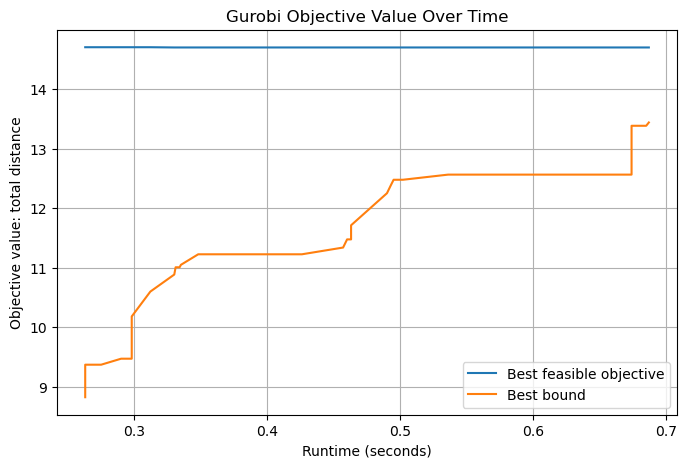


Solving with demand loss limit = 1058


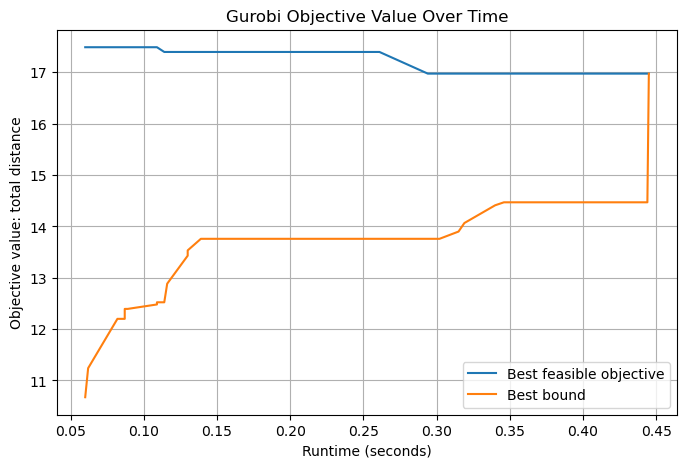


Solving with demand loss limit = 705


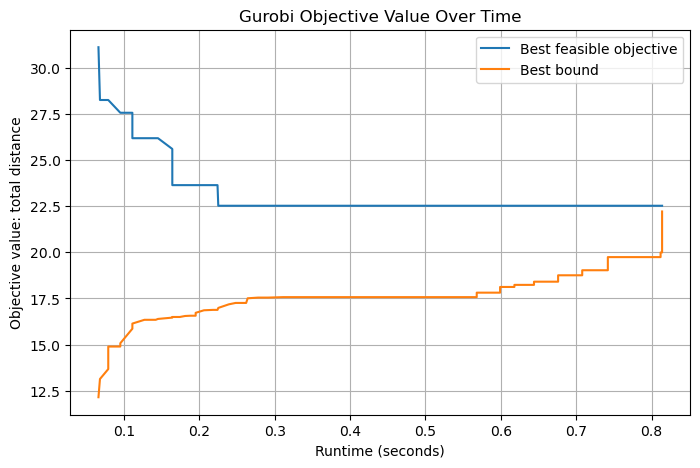


Solving with demand loss limit = 352


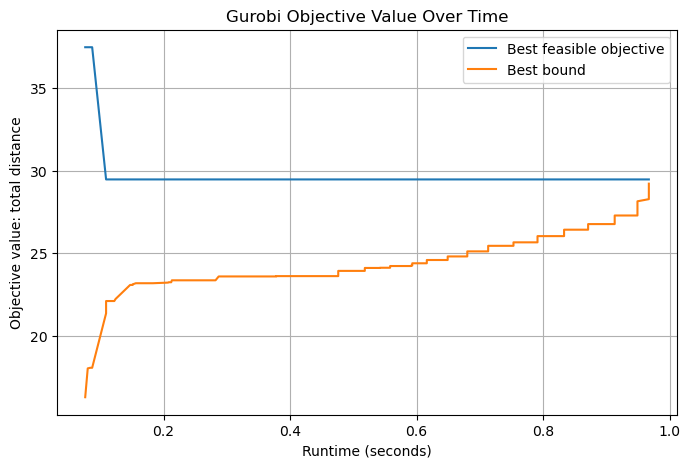


Solving with demand loss limit = 0
No feasible solution found.
Gurobi status: 9
Skipped epsilon = 0 because no feasible solution was found.

GUROBI EPSILON-CONSTRAINT BENCHMARK RESULTS
Solution   Distance        Demand Loss     Served Demand   Runtime    MIP Gap   


In [35]:
import math
import random
import matplotlib.pyplot as plt
from gurobipy import Model, GRB, quicksum

# ============================================================
# 1. Generate small synthetic data
# ============================================================

def generate_data(num_stops=10, num_services=3, seed=42):
    random.seed(seed)

    depot = 0
    stops = list(range(1, num_stops + 1))
    nodes = [depot] + stops
    services = list(range(num_services))

    # Generate coordinates in a 10 km by 10 km area
    coords = {depot: (5.0, 5.0)}

    for i in stops:
        coords[i] = (
            random.uniform(0, 10),
            random.uniform(0, 10)
        )

    # Euclidean distance matrix
    distance = {}

    for i in nodes:
        for j in nodes:
            if i != j:
                xi, yi = coords[i]
                xj, yj = coords[j]
                distance[i, j] = math.sqrt((xi - xj) ** 2 + (yi - yj) ** 2)

    # Peak-period demand at each stop
    demand = {
        i: random.randint(80, 500)
        for i in stops
    }

    return nodes, stops, depot, services, coords, distance, demand

# ============================================================
# 2. Solve one epsilon-constraint model
# ============================================================
def solve_bus_route_gurobi(
    nodes,
    stops,
    depot,
    services,
    distance,
    demand,
    max_stops_per_service=4,
    max_distance_per_service=None,
    demand_loss_limit=None,
    time_limit=60,
    verbose=False,
    plot_progress=True
):
    """
    Solves one epsilon-constraint version of the bi-objective bus route redesign problem.

    Objective:
        Minimise total travel distance.

    Constraint:
        Demand loss <= demand_loss_limit.

    Also records Gurobi objective value over time using a callback.
    """

    model = Model("bus_route_redesign_mtsp")

    if not verbose:
        model.Params.OutputFlag = 0

    model.Params.TimeLimit = time_limit

    Z = services
    N = nodes
    V = stops
    K = max_stops_per_service

    # ------------------------------------------------------------
    # Decision variables
    # ------------------------------------------------------------

    x = {}

    for z in Z:
        for i in N:
            for j in N:
                if i != j:
                    x[z, i, j] = model.addVar(
                        vtype=GRB.BINARY,
                        name=f"x_{z}_{i}_{j}"
                    )

    y = {}

    for z in Z:
        for i in V:
            y[z, i] = model.addVar(
                vtype=GRB.BINARY,
                name=f"y_{z}_{i}"
            )

    u = {}

    for i in V:
        u[i] = model.addVar(
            vtype=GRB.BINARY,
            name=f"u_{i}"
        )

    order = {}

    for z in Z:
        for i in V:
            order[z, i] = model.addVar(
                lb=0,
                ub=K,
                vtype=GRB.CONTINUOUS,
                name=f"order_{z}_{i}"
            )

    model.update()

    # ------------------------------------------------------------
    # Constraints
    # ------------------------------------------------------------

    # Each service leaves depot exactly once
    for z in Z:
        model.addConstr(
            quicksum(x[z, depot, j] for j in V) == 1,
            name=f"depart_depot_{z}"
        )

    # Each service returns depot exactly once
    for z in Z:
        model.addConstr(
            quicksum(x[z, i, depot] for i in V) == 1,
            name=f"return_depot_{z}"
        )

    # Link route flow to assignment
    for z in Z:
        for i in V:
            model.addConstr(
                quicksum(x[z, i, j] for j in N if j != i) == y[z, i],
                name=f"outflow_link_{z}_{i}"
            )

            model.addConstr(
                quicksum(x[z, j, i] for j in N if j != i) == y[z, i],
                name=f"inflow_link_{z}_{i}"
            )

    # Each stop assigned to at most one service
    for i in V:
        model.addConstr(
            quicksum(y[z, i] for z in Z) >= 0,
            name=f"at_most_one_service_{i}"
        )

    # Coverage variable
    for i in V:
        model.addConstr(
            u[i] <= quicksum(y[z, i] for z in Z),
            name=f"coverage_{i}"
        )

    # Maximum stops per service
    for z in Z:
        model.addConstr(
            quicksum(y[z, i] for i in V) <= K,
            name=f"max_stops_service_{z}"
        )

    # Optional maximum distance per service
    if max_distance_per_service is not None:
        for z in Z:
            model.addConstr(
                quicksum(
                    distance[i, j] * x[z, i, j]
                    for i in N
                    for j in N
                    if i != j
                ) <= max_distance_per_service,
                name=f"max_route_distance_{z}"
            )

    # MTZ subtour elimination
    for z in Z:
        for i in V:
            model.addConstr(
                order[z, i] >= y[z, i],
                name=f"order_lower_{z}_{i}"
            )

            model.addConstr(
                order[z, i] <= K * y[z, i],
                name=f"order_upper_{z}_{i}"
            )

        for i in V:
            for j in V:
                if i != j:
                    model.addConstr(
                        order[z, i] - order[z, j] + K * x[z, i, j]
                        <= K - 1,
                        name=f"mtz_{z}_{i}_{j}"
                    )

    # Demand loss
    total_demand = sum(demand[i] for i in V)

    served_demand = quicksum(
        demand[i] * u[i]
        for i in V
    )

    demand_loss = total_demand - served_demand

    if demand_loss_limit is not None:
        model.addConstr(
            demand_loss <= demand_loss_limit,
            name="demand_loss_limit"
        )

    # Total travel distance objective
    total_distance = quicksum(
        distance[i, j] * x[z, i, j]
        for z in Z
        for i in N
        for j in N
        if i != j
    )

    model.setObjective(total_distance, GRB.MINIMIZE)

    # ------------------------------------------------------------
    # Callback storage
    # ------------------------------------------------------------

    progress = {
        "time": [],
        "incumbent": [],
        "best_bound": []
    }

    def mip_callback(model, where):
        if where == GRB.Callback.MIP:
            runtime = model.cbGet(GRB.Callback.RUNTIME)
            best_obj = model.cbGet(GRB.Callback.MIP_OBJBST)
            best_bound = model.cbGet(GRB.Callback.MIP_OBJBND)

            # Gurobi uses very large values before any incumbent is found
            if best_obj < GRB.INFINITY:
                progress["time"].append(runtime)
                progress["incumbent"].append(best_obj)
                progress["best_bound"].append(best_bound)

    # ------------------------------------------------------------
    # Solve
    # ------------------------------------------------------------

    model.optimize(mip_callback)

    # ------------------------------------------------------------
    # Important fix:
    # only access .X if Gurobi found at least one feasible solution
    # ------------------------------------------------------------

    if model.SolCount == 0:
        print("No feasible solution found.")
        print("Gurobi status:", model.Status)
        return None

    # ------------------------------------------------------------
    # Extract routes safely
    # ------------------------------------------------------------

    routes = {}

    for z in Z:
        route = [depot]
        current = depot
        visited_in_route = set()

        while True:
            next_node = None

            for j in N:
                if current != j and (z, current, j) in x:
                    if x[z, current, j].X > 0.5:
                        next_node = j
                        break

            if next_node is None:
                break

            route.append(next_node)

            if next_node == depot:
                break

            if next_node in visited_in_route:
                print(f"Warning: repeated node detected in route for service {z}")
                break

            visited_in_route.add(next_node)
            current = next_node

        routes[z] = route

    selected_stops = [
        i for i in V
        if u[i].X > 0.5
    ]

    unserved_stops = [
        i for i in V
        if u[i].X < 0.5
    ]

    result = {
        "status": model.Status,
        "objective_distance": total_distance.getValue(),
        "demand_loss": demand_loss.getValue(),
        "served_demand": served_demand.getValue(),
        "total_demand": total_demand,
        "runtime": model.Runtime,
        "mip_gap": model.MIPGap if model.SolCount > 0 else None,
        "routes": routes,
        "selected_stops": selected_stops,
        "unserved_stops": unserved_stops,
        "demand": demand,
        "progress": progress
    }

    

    # ------------------------------------------------------------
    # Plot objective value over time
    # ------------------------------------------------------------

    if plot_progress and len(progress["time"]) > 0:
        plt.figure(figsize=(8, 5))
        plt.plot(progress["time"], progress["incumbent"], label="Best feasible objective")
        plt.plot(progress["time"], progress["best_bound"], label="Best bound")
        plt.xlabel("Runtime (seconds)")
        plt.ylabel("Objective value: total distance")
        plt.title("Gurobi Objective Value Over Time")
        plt.legend()
        plt.grid(True)
        plt.show()

    return result

def run_epsilon_constraint_experiment():
    nodes, stops, depot, services, coords, distance, demand = generate_data(
        num_stops=10,
        num_services=3,
        seed=7
    )

    total_demand = sum(demand[i] for i in stops)

    print("\nGenerated stop demand:")
    for i in stops:
        print(f"Stop {i}: demand = {demand[i]}")

    print("\nTotal demand:", total_demand)

    # Because 3 services x 4 stops each = maximum 12 stops,
    # all 10 stops can theoretically be served.
    epsilon_values = [
        int(total_demand * 0.60),
        int(total_demand * 0.45),
        int(total_demand * 0.30),
        int(total_demand * 0.15),
        0
    ]

    pareto_results = []

    for eps in epsilon_values:
        print(f"\nSolving with demand loss limit = {eps}")
    
        result = solve_bus_route_gurobi(
            nodes=nodes,
            stops=stops,
            depot=depot,
            services=services,
            distance=distance,
            demand=demand,
            max_stops_per_service=4,
            max_distance_per_service=None,
            demand_loss_limit=eps,
            time_limit=60,
            verbose=False,
            plot_progress=True
        )

    if result is not None:
        pareto_results.append(result)
    else:
        print(f"Skipped epsilon = {eps} because no feasible solution was found.")

    # Remove duplicate solutions
    unique_results = []
    seen = set()

    for result in pareto_results:
        key = (
            round(result["objective_distance"], 4),
            round(result["demand_loss"], 4)
        )

        if key not in seen:
            seen.add(key)
            unique_results.append(result)

    print("\n" + "=" * 90)
    print("GUROBI EPSILON-CONSTRAINT BENCHMARK RESULTS")
    print("=" * 90)

    print(
        f"{'Solution':<10} "
        f"{'Distance':<15} "
        f"{'Demand Loss':<15} "
        f"{'Served Demand':<15} "
        f"{'Runtime':<10} "
        f"{'MIP Gap':<10}"
    )

    for idx, result in enumerate(unique_results, start=1):
        print(
            f"{idx:<10} "
            f"{result['objective_distance']:<15.3f} "
            f"{result['demand_loss']:<15.1f} "
            f"{result['served_demand']:<15.1f} "
            f"{result['runtime']:<10.3f} "
            f"{result['mip_gap']:<10.5f}"
        )

    for idx, result in enumerate(unique_results, start=1):
        print("\n" + "-" * 90)
        print(f"Solution {idx}")
        print("-" * 90)

        print(f"Total distance: {result['objective_distance']:.3f}")
        print(f"Demand loss:    {result['demand_loss']:.1f}")
        print(f"Served demand:  {result['served_demand']:.1f}")
        print(f"Unserved stops: {result['unserved_stops']}")

        for z, route in result["routes"].items():
            print(f"Service {z}: {route}")

    return unique_results


# ============================================================
# 4. Main
# ============================================================

results = run_epsilon_constraint_experiment()